ДЕРЕВЬЯ РЕШЕНИЙ И АНСАМБЛИ

Деревья решений

In [1]:
from __future__ import annotations

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# датасеты
from sklearn.datasets import make_moons, load_breast_cancer

# разбиение на train/test и метрики качества
from sklearn.model_selection import (
    train_test_split, 
    StratifiedKFold, 
    cross_val_predict, 
    GridSearchCV
    )

from sklearn.metrics import (accuracy_score, 
    f1_score,
    roc_auc_score, 
    confusion_matrix, 
    RocCurveDisplay
    )

# модель дерева, визуализация структуры и экспорт правил, пайплайн
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier

# важность признаков через перемешивание
from sklearn.inspection import permutation_importance

# Ансамбли
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier,
)

import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("Artifacts dir:", ARTIFACTS_DIR.resolve())

Artifacts dir: C:\Users\User\Desktop\al\artificial-intelligence\homeworks\HW06\artifacts


Вспомогательные функции

In [2]:
# - print_metrics: компактно печатает метрики и confusion matrix
# - plot_decision_boundary_2d: рисует границу решений на 2D (для интуиции)

def print_metrics(y_true, y_pred, y_proba=None, title=None):
    # y_true, y_pred: истинные и предсказанные метки классов (например, 0/1)
    # y_proba: вероятность класса 1 (нужна, если хотим посчитать ROC-AUC)
    if title:
        print(title)
    # Accuracy – доля правильных ответов (хороша как “первая” метрика, но не всегда достаточно)
    acc = accuracy_score(y_true, y_pred)
    # F1 – баланс precision/recall (часто полезнее accuracy при дисбалансе классов)
    f1 = f1_score(y_true, y_pred)
    print(f"accuracy = {acc:.4f}")
    print(f"f1       = {f1:.4f}")
    if y_proba is not None:
        # ROC-AUC корректно считать по вероятностям/скорингам, а не по “жёстким” классам
        try:
            auc = roc_auc_score(y_true, y_proba)
            print(f"roc_auc  = {auc:.4f}")
        except Exception:
            # Иногда AUC может не считаться (например, если в y_true один класс)
            pass
    print("confusion_matrix:")
    print(confusion_matrix(y_true, y_pred))
    print()

def plot_decision_boundary_2d(model, X, y, title=None, steps=300):
    # Работает только для 2D признаков (чисто для визуального понимания)
    # Идея: строим сетку точек, предсказываем класс в каждой – получаем “карту” решений
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, steps),
                         np.linspace(y_min, y_max, steps))
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, zz, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=20)
    if title:
        plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()


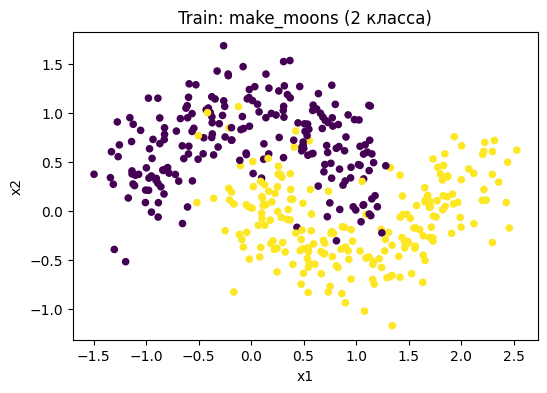

In [3]:
# noise - добавление шума
X, y = make_moons(n_samples=600, noise=0.25, random_state=RANDOM_STATE)

# разбиваем на train/test
# stratify=y - сохранения доли классов в обеих выборках
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

# визуализация
plt.figure(figsize=(6, 4))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=20)
plt.title("Train: make_moons (2 класса)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

Обучение дерева

In [4]:
# Обучаем “полное” дерево (без явных ограничений сложности).
# у DecisionTreeClassifier по умолчанию max_depth=None, дерево растёт, пока может улучшать критерий
tree_full = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree_full.fit(X_train, y_train)

# сравнение качества на train/test
y_pred_train = tree_full.predict(X_train)
y_pred_test = tree_full.predict(X_test)

print_metrics(y_train, y_pred_train, title="FULL TREE – train")
print_metrics(y_test, y_pred_test, title="FULL TREE – test")

FULL TREE – train
accuracy = 1.0000
f1       = 1.0000
confusion_matrix:
[[210   0]
 [  0 210]]

FULL TREE – test
accuracy = 0.8778
f1       = 0.8830
confusion_matrix:
[[75 15]
 [ 7 83]]



Рисуем границы

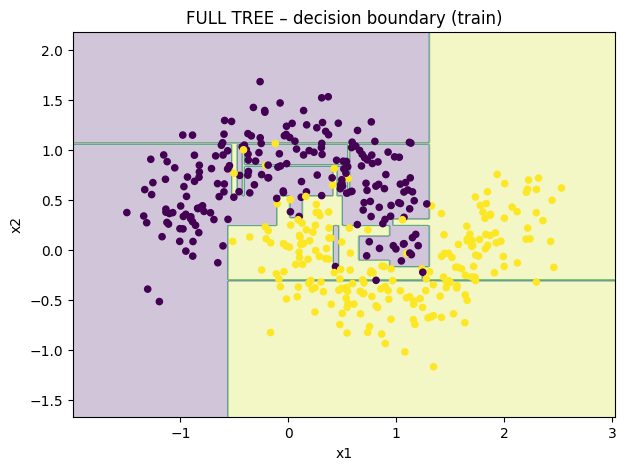

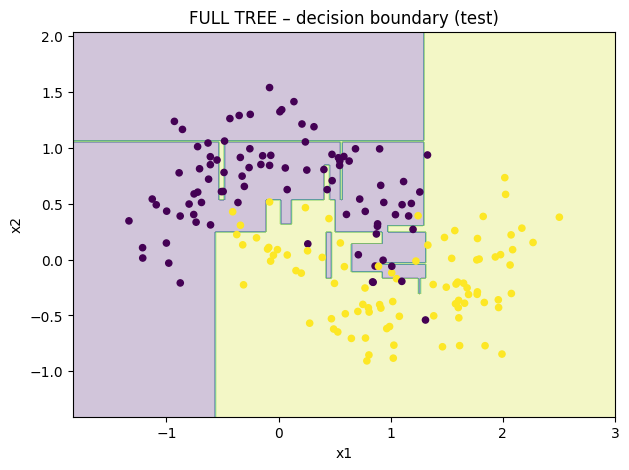

In [5]:
plot_decision_boundary_2d(tree_full, X_train, y_train, title="FULL TREE – decision boundary (train)")
plot_decision_boundary_2d(tree_full, X_test, y_test, title="FULL TREE – decision boundary (test)")  

Так как мы не задали max_depth, модель переобучилась,это вчастности можно понять по сложности границы, показала идеальные результаты на train и не очень хорошие на test, так так обобщающая способность была утеряна, один из способов избавиться от переобучения - это регуляризация, которая уменьшает число разбиений

Структура дерева

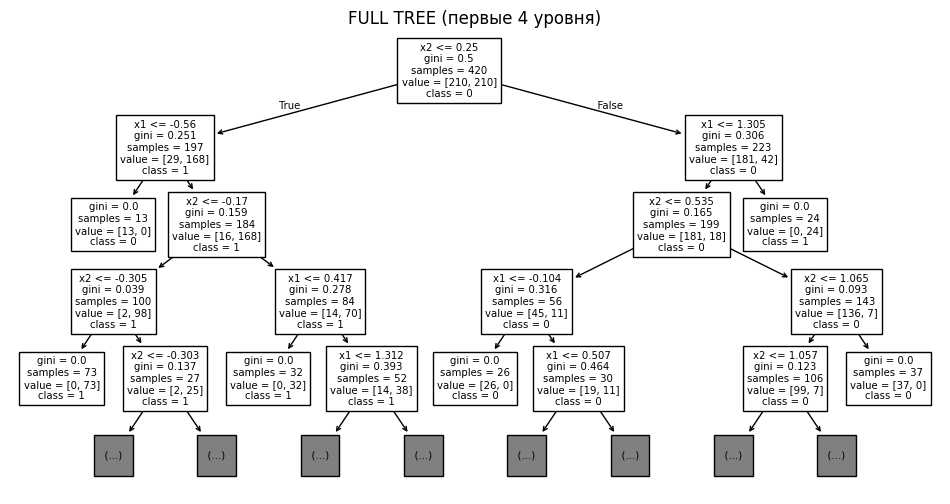

In [6]:
# Визуализируем первые уровни дерева
# max_depth здесь ограничивает только визуализацию, а не само обученное дерево.
plt.figure(figsize=(12, 6))
plot_tree(tree_full, max_depth=4, filled=False, feature_names=["x1", "x2"], class_names=["0", "1"])
plt.title("FULL TREE (первые 4 уровня)")
plt.show()

In [7]:
# Экспортируем дерево в текстовый вид правил.
# Это удобный способ “прочитать” модель: сверху вниз по веткам.
rules = export_text(tree_full, feature_names=["x1", "x2"], max_depth=3)
print(rules)

|--- x2 <= 0.25
|   |--- x1 <= -0.56
|   |   |--- class: 0
|   |--- x1 >  -0.56
|   |   |--- x2 <= -0.17
|   |   |   |--- x2 <= -0.31
|   |   |   |   |--- class: 1
|   |   |   |--- x2 >  -0.31
|   |   |   |   |--- truncated branch of depth 4
|   |   |--- x2 >  -0.17
|   |   |   |--- x1 <= 0.42
|   |   |   |   |--- class: 1
|   |   |   |--- x1 >  0.42
|   |   |   |   |--- truncated branch of depth 7
|--- x2 >  0.25
|   |--- x1 <= 1.31
|   |   |--- x2 <= 0.54
|   |   |   |--- x1 <= -0.10
|   |   |   |   |--- class: 0
|   |   |   |--- x1 >  -0.10
|   |   |   |   |--- truncated branch of depth 5
|   |   |--- x2 >  0.54
|   |   |   |--- x2 <= 1.06
|   |   |   |   |--- truncated branch of depth 11
|   |   |   |--- x2 >  1.06
|   |   |   |   |--- class: 0
|   |--- x1 >  1.31
|   |   |--- class: 1



График переобучения

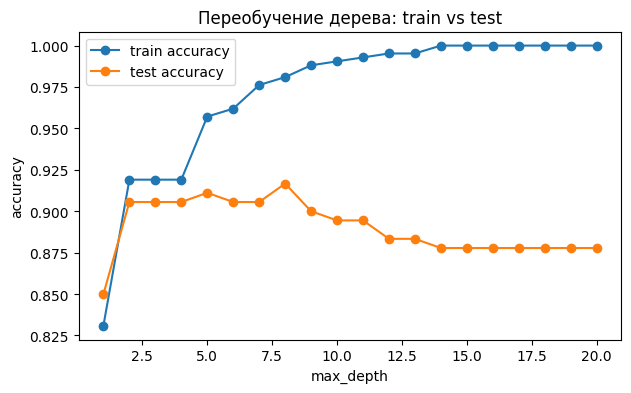

In [8]:
# влияние глуины на переобучение
depths = list(range(1,21))
train_acc = []
test_acc = []

for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    m.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, m.predict(X_train)))
    test_acc.append(accuracy_score(y_test, m.predict(X_test)))

#  график зависимости accuracy от глубины дерева
plt.figure(figsize=(7, 4))
plt.plot(depths, train_acc, marker="o", label="train accuracy")
plt.plot(depths, test_acc, marker="o", label="test accuracy")
plt.xlabel("max_depth")
plt.ylabel("accuracy")
plt.title("Переобучение дерева: train vs test")
plt.legend()
plt.show()


Добавляем контроль сложности

REGULARIZED TREE – train
accuracy = 0.9571
f1       = 0.9571
confusion_matrix:
[[201   9]
 [  9 201]]

REGULARIZED TREE – test
accuracy = 0.9222
f1       = 0.9239
confusion_matrix:
[[81  9]
 [ 5 85]]



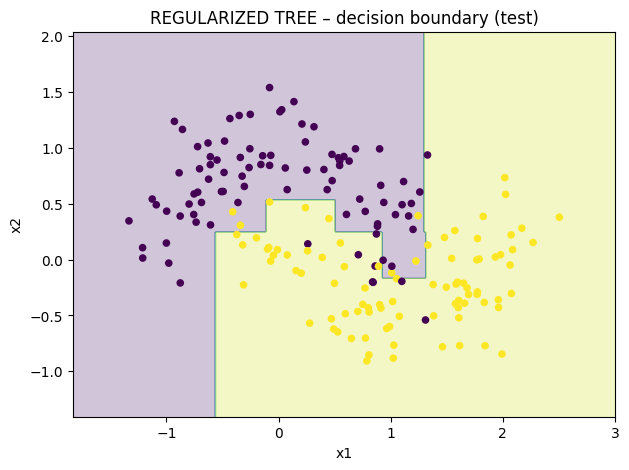

In [9]:
# max_depth - ограничение последовательных разбиений
# min_samples_leaf - требование на минимальное количество объектов в листе
tree_reg = DecisionTreeClassifier(
    max_depth=7,
    min_samples_leaf=10,
    random_state=RANDOM_STATE
)
tree_reg.fit(X_train, y_train)

print_metrics(y_train, tree_reg.predict(X_train), title="REGULARIZED TREE – train")
print_metrics(y_test, tree_reg.predict(X_test),title="REGULARIZED TREE – test")

plot_decision_boundary_2d(tree_reg, X_test, y_test, title="REGULARIZED TREE – decision boundary (test)")

После регуляризации граница становиться более гладкой, так как регуляризация увеличивает обобщающие способности модели, модель становиться менее чувствительной к шуму

Cost-Complexity Pruning(CCP)

In [10]:
path = tree_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

ccp_alphas = np.unique(ccp_alphas)
if len(ccp_alphas) > 60:
    ccp_alphas = ccp_alphas[:: max(1, len(ccp_alphas)//60)]

train_scores = []
test_scores = []
node_counts = []

models = []
for a in ccp_alphas:
    m = DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=float(a))
    m.fit(X_train, y_train)
    models.append(m)
    train_scores.append(accuracy_score(y_train, m.predict(X_train)))
    test_scores.append(accuracy_score(y_test, m.predict(X_test)))
    node_counts.append(m.tree_.node_count)

# выбираем alpha по качеству на test
best_idx = int(np.argmax(test_scores))
best_alpha = float(ccp_alphas[best_idx])
best_model = models[best_idx]

best_alpha, test_scores[best_idx], node_counts[best_idx]

(0.0026418026418026422, 0.9277777777777778, 35)

График изменения качества при росте alphas

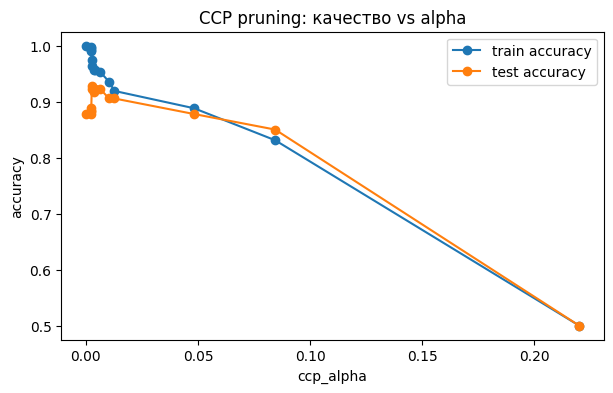

In [11]:
plt.figure(figsize=(7, 4))
plt.plot(ccp_alphas, train_scores, marker="o", label="train accuracy")
plt.plot(ccp_alphas, test_scores, marker="o", label="test accuracy")
plt.xlabel("ccp_alpha")
plt.ylabel("accuracy")
plt.title("CCP pruning: качество vs alpha")
plt.legend()
plt.show()

Лучшее alpha по test accuracy: 0.0026418026418026422
BEST CCP TREE – test
accuracy = 0.9278
f1       = 0.9282
confusion_matrix:
[[83  7]
 [ 6 84]]



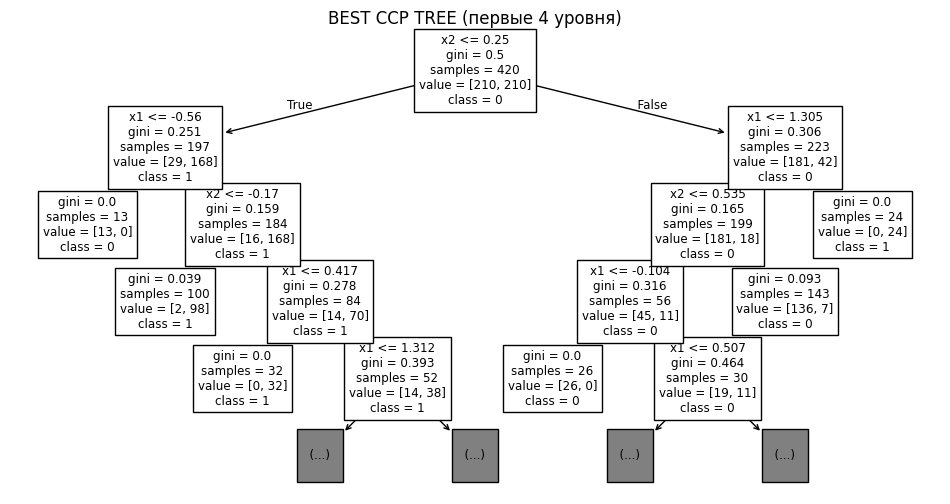

In [12]:
# Фиксируем лучший alpha и смотрим итоговое качество.
print(f"Лучшее alpha по test accuracy: {best_alpha}")
print_metrics(y_test, best_model.predict(X_test), title="BEST CCP TREE – test")

# И визуализируем “обрезанное” дерево (первые уровни).
plt.figure(figsize=(12, 6))
plot_tree(best_model, max_depth=4, filled=False, feature_names=["x1", "x2"], class_names=["0", "1"])
plt.title("BEST CCP TREE (первые 4 уровня)")
plt.show()

Мини-практика

In [13]:
data = load_breast_cancer()
X = data["data"]
y = data["target"]
feature_names = list(data["feature_names"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

# регуляризированное дерево
tree = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    max_depth=7,
    min_samples_leaf=10
)
tree.fit(X_train, y_train)

# ROC-AUC 
proba_test = tree.predict_proba(X_test)[:, 1]
# берем стандартный порог
pred_test = (proba_test >= 0.5).astype(int)

print_metrics(y_test, pred_test, y_proba=proba_test, title="Breast cancer – DecisionTree")


Breast cancer – DecisionTree
accuracy = 0.9510
f1       = 0.9613
roc_auc  = 0.9828
confusion_matrix:
[[49  4]
 [ 3 87]]



Permutation importance

Важность признаков на результат, случайно перемешивает значения одного признака

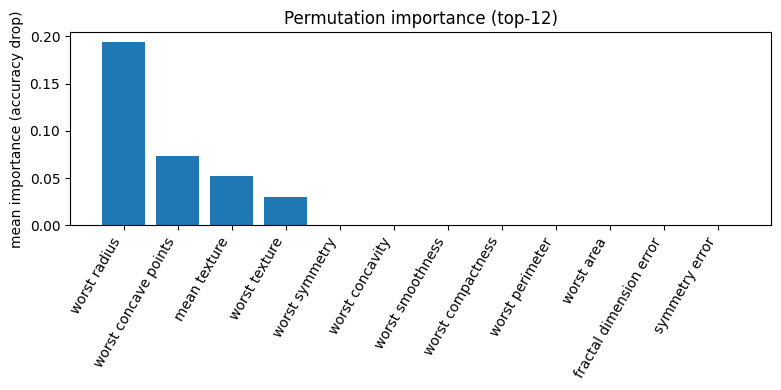

In [14]:
# Permutation importance: по очереди перемешиваем один признак и смотрим, насколько падает качество
perm = permutation_importance(
    tree, X_test, y_test,
    n_repeats=12,
    random_state=RANDOM_STATE,
    scoring="accuracy"
)

importances = perm.importances_mean
idx = np.argsort(importances)[::-1][:12]

plt.figure(figsize=(8, 4))
plt.bar(range(len(idx)), importances[idx])
plt.xticks(range(len(idx)), [feature_names[i] for i in idx], rotation=60, ha="right")
plt.ylabel("mean importance (accuracy drop)")
plt.title("Permutation importance (top-12)")
plt.tight_layout()
plt.show()

АНСАМБЛИ

Bagging

Bagging (bootstrap aggregating) строит много моделей на “псевдо-выборках”, полученных из исходной обучающей выборки с помощью bootstrap: мы случайно выбираем объекты с возвращением.

Что это даёт:

часть объектов попадёт несколько раз (дубли);
часть объектов не попадёт вообще;
каждая модель видит “свою” версию данных → ошибки разных моделей становятся менее синхронными.

In [15]:
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier

Вспомогательные функции

In [16]:
def print_metrics(y_true, y_pred, y_proba=None, title=None):
    if title:
        print(title)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"accuracy = {acc:.4f}")
    print(f"f1       = {f1:.4f}")
    if y_proba is not None:
        try:
            auc = roc_auc_score(y_true, y_proba)
            print(f"roc_auc  = {auc:.4f}")
        except Exception:
            pass
    print("confusion_matrix:")
    print(confusion_matrix(y_true, y_pred))
    print()

def plot_decision_boundary_2d(model, X, y, title=None, steps=300):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, steps),
                         np.linspace(y_min, y_max, steps))
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, zz, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=20)
    if title:
        plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

def make_bagging_tree(estimator, n_estimators=200, random_state=42, oob_score=True, n_jobs=-1):
    # совместимость с разными версиями sklearn
    try:
        return BaggingClassifier(
            estimator=estimator,
            n_estimators=n_estimators,
            bootstrap=True,
            oob_score=oob_score,
            n_jobs=n_jobs,
            random_state=random_state
        )
    except TypeError:
        return BaggingClassifier(
            base_estimator=estimator,
            n_estimators=n_estimators,
            bootstrap=True,
            oob_score=oob_score,
            n_jobs=n_jobs,
            random_state=random_state
        )
     

Проверка доли уникальных объектов экспериментально

Средняя доля уникальных объектов: 0.632
Минимум/максимум: 0.605 / 0.653


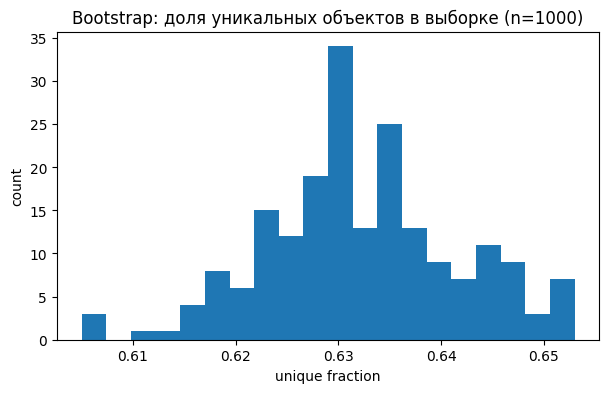

In [17]:
n = 1000
trials = 200

uniq_frac = []
for _ in range(trials):
    idx = np.random.randint(0, n, size=n)  # bootstrap sample, size=n
    uniq_frac.append(len(np.unique(idx)) / n)

print(f"Средняя доля уникальных объектов: {np.mean(uniq_frac):.3f}")
print(f"Минимум/максимум: {np.min(uniq_frac):.3f} / {np.max(uniq_frac):.3f}")

plt.figure(figsize=(7, 4))
plt.hist(uniq_frac, bins=20)
plt.xlabel("unique fraction")
plt.ylabel("count")
plt.title("Bootstrap: доля уникальных объектов в выборке (n=1000)")
plt.show()

Сравнение

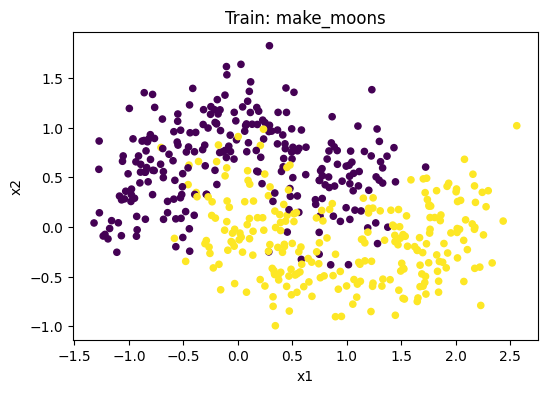

In [18]:
X, y = make_moons(n_samples=700, noise=0.28, random_state=RANDOM_STATE)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

plt.figure(figsize=(6, 4))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=20)
plt.title("Train: make_moons")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

Одиночное дерево

DecisionTree – test
accuracy = 0.8905
f1       = 0.8940
confusion_matrix:
[[90 15]
 [ 8 97]]



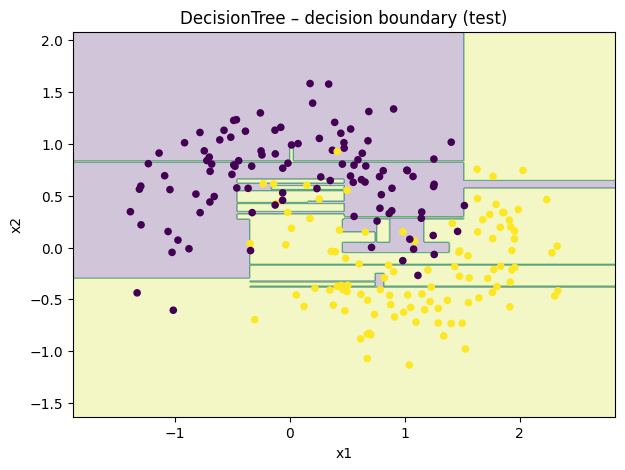

In [19]:
tree = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=None)
tree.fit(X_train, y_train)

print_metrics(y_test, tree.predict(X_test), title="DecisionTree – test")
plot_decision_boundary_2d(tree, X_test, y_test, title="DecisionTree – decision boundary (test)")

Bagging деревьев

Bagging строит много моделей на bootstrap-выборках и агрегирует ответы (для классификации – обычно голосование).

Интуиция:

если отдельные деревья шумные и переобучаются, то усреднение/голосование “сглаживает” ошибки;
качество становится более стабильным.
Параметры, на которые стоит смотреть:

n_estimators – сколько деревьев в ансамбле (больше - стабильнее, но медленнее);
bootstrap=True – включаем bootstrap;
oob_score=True – попросим модель оценить себя “по объектам вне bootstrap”

Bagging oob_score_ = 0.8959183673469387
Bagging(DecisionTree) – test
accuracy = 0.9095
f1       = 0.9116
confusion_matrix:
[[93 12]
 [ 7 98]]



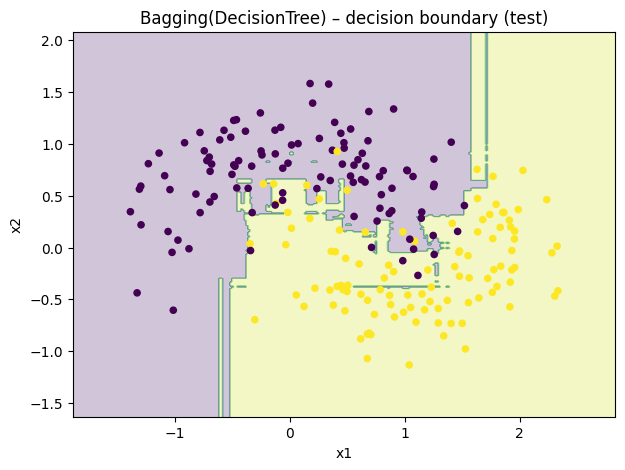

In [20]:
# base_tree
base_tree = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=None)

bag = make_bagging_tree(base_tree, n_estimators=250, random_state=RANDOM_STATE, oob_score=True, n_jobs=-1)
bag.fit(X_train, y_train)

print(f"Bagging oob_score_ = {getattr(bag, 'oob_score_', None)}")
print_metrics(y_test, bag.predict(X_test), title="Bagging(DecisionTree) – test")
plot_decision_boundary_2d(bag, X_test, y_test, title="Bagging(DecisionTree) – decision boundary (test)")
     

Random Forest

Random Forest делает всё то же, что bagging, но добавляет ещё один источник разнообразия:

на каждом разбиении дерева рассматривается случайное подмножество признаков.
Зачем это нужно:

деревья в bagging могут быть сильно коррелированы (особенно если есть “очень сильный” признак);
случайность по признакам уменьшает корреляцию деревьев → ансамбль становится ещё сильнее.
Ключевые параметры:

n_estimators – число деревьев;
max_features – сколько признаков пробовать на каждом split;
max_depth / min_samples_leaf – ограничения сложности (можно использовать как регуляризацию).

RandomForest oob_score_ = 0.8714
RandomForest – test
accuracy = 0.9095
f1       = 0.9108
confusion_matrix:
[[94 11]
 [ 8 97]]



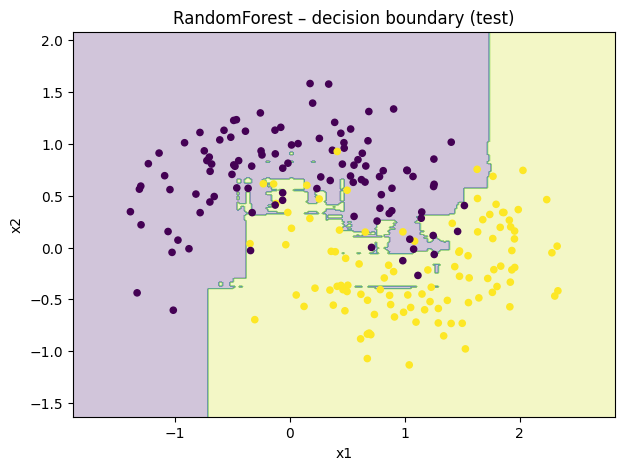

In [21]:
rf = RandomForestClassifier(
    n_estimators=400,
    random_state=RANDOM_STATE,
    oob_score=True,
    n_jobs=-1,
    max_features="log2"
)
rf.fit(X_train, y_train)

print(f"RandomForest oob_score_ = {rf.oob_score_:.4f}")
print_metrics(y_test, rf.predict(X_test), title="RandomForest – test")
plot_decision_boundary_2d(rf, X_test, y_test, title="RandomForest – decision boundary (test)")
     

Если модель сильно зависима от случайности, то random_state метрики имеют большой разброс
Если модель устойчива, разброс будет меньше

In [22]:
seeds = list(range(0, 20))

acc_tree = []
acc_bag = []
acc_rf = []

for s in seeds:
    t = DecisionTreeClassifier(random_state=s, max_depth=None)
    t.fit(X_train, y_train)
    acc_tree.append(accuracy_score(y_test, t.predict(X_test)))

    b = make_bagging_tree(DecisionTreeClassifier(random_state=s, max_depth=None),
                          n_estimators=200, random_state=s, oob_score=False, n_jobs=-1)
    b.fit(X_train, y_train)
    acc_bag.append(accuracy_score(y_test, b.predict(X_test)))

    r = RandomForestClassifier(n_estimators=300, random_state=s, n_jobs=-1)
    r.fit(X_train, y_train)
    acc_rf.append(accuracy_score(y_test, r.predict(X_test)))

print(f"DecisionTree: mean={np.mean(acc_tree):.4f}, std={np.std(acc_tree):.4f}")
print(f"Bagging:      mean={np.mean(acc_bag):.4f}, std={np.std(acc_bag):.4f}")
print(f"RandForest:   mean={np.mean(acc_rf):.4f}, std={np.std(acc_rf):.4f}")

DecisionTree: mean=0.8888, std=0.0051
Bagging:      mean=0.9079, std=0.0041
RandForest:   mean=0.9086, std=0.0039


Распеределение метрик 

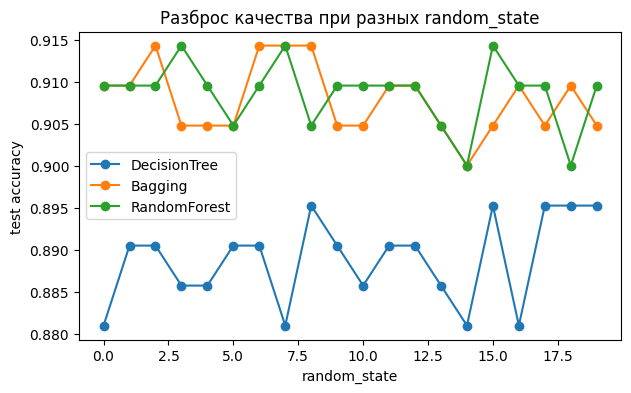

In [23]:
plt.figure(figsize=(7, 4))
plt.plot(seeds, acc_tree, marker="o", label="DecisionTree")
plt.plot(seeds, acc_bag, marker="o", label="Bagging")
plt.plot(seeds, acc_rf, marker="o", label="RandomForest")
plt.xlabel("random_state")
plt.ylabel("test accuracy")
plt.title("Разброс качества при разных random_state")
plt.legend()
plt.show()

Одиночное дерево даёт заметный разброс качества (особенно на шумных данных);
bagging уменьшает разброс;
random forest часто уменьшает разброс ещё сильнее.

Ансамбли уменьшают variance за счёт усреднения и уменьшения корреляции между базовыми моделями.


OOB(Out-of-Bag)

OOB-score – это агрегированная оценка качества ансамбля по объектам, которые были “вне bootstrap” для каждого базового алгоритма.

In [24]:
print(f"Bagging oob_score_      = {getattr(bag, 'oob_score_', None)}")
print(f"RandomForest oob_score_ = {rf.oob_score_:.4f}")

print(f"Bagging test accuracy   = {accuracy_score(y_test, bag.predict(X_test)):.4f}")
print(f"RF test accuracy        = {accuracy_score(y_test, rf.predict(X_test)):.4f}")
     

Bagging oob_score_      = 0.8959183673469387
RandomForest oob_score_ = 0.8714
Bagging test accuracy   = 0.9095
RF test accuracy        = 0.9095


In [25]:
data = load_breast_cancer()
X = data["data"]
y = data["target"]
feature_names = list(data["feature_names"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

tree_tab = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=None)
tree_tab.fit(X_train, y_train)

rf_tab = RandomForestClassifier(
    n_estimators=600,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    oob_score=True
)
rf_tab.fit(X_train, y_train)

proba_tree = tree_tab.predict_proba(X_test)[:, 1]
proba_rf = rf_tab.predict_proba(X_test)[:, 1]

print_metrics(y_test, (proba_tree >= 0.5).astype(int), y_proba=proba_tree, title="Tabular – DecisionTree")
print_metrics(y_test, (proba_rf >= 0.5).astype(int), y_proba=proba_rf, title="Tabular – RandomForest")
print(f"RandomForest oob_score_ = {rf_tab.oob_score_:.4f}")

Tabular – DecisionTree
accuracy = 0.9231
f1       = 0.9379
roc_auc  = 0.9234
confusion_matrix:
[[49  4]
 [ 7 83]]

Tabular – RandomForest
accuracy = 0.9580
f1       = 0.9670
roc_auc  = 0.9943
confusion_matrix:
[[49  4]
 [ 2 88]]

RandomForest oob_score_ = 0.9624


feature_importances_ в деревьях/лесах обычно основана на том, насколько признак уменьшал impurity (например, Gini) по всем разбиениям.

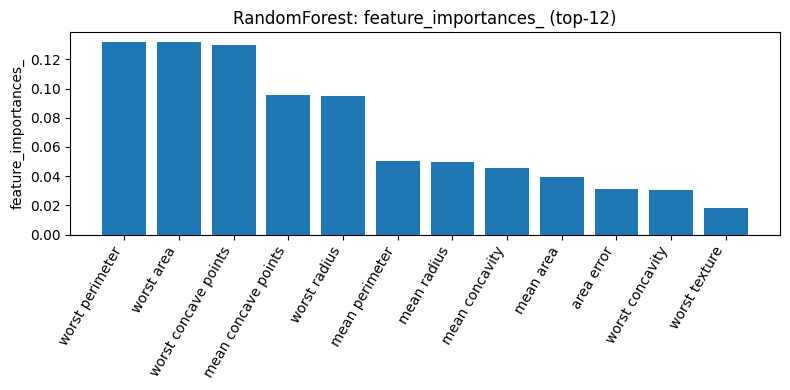

In [26]:
importances = rf_tab.feature_importances_
idx = np.argsort(importances)[::-1][:12]

plt.figure(figsize=(8, 4))
plt.bar(range(len(idx)), importances[idx])
plt.xticks(range(len(idx)), [feature_names[i] for i in idx], rotation=60, ha="right")
plt.ylabel("feature_importances_")
plt.title("RandomForest: feature_importances_ (top-12)")
plt.tight_layout()
plt.show()

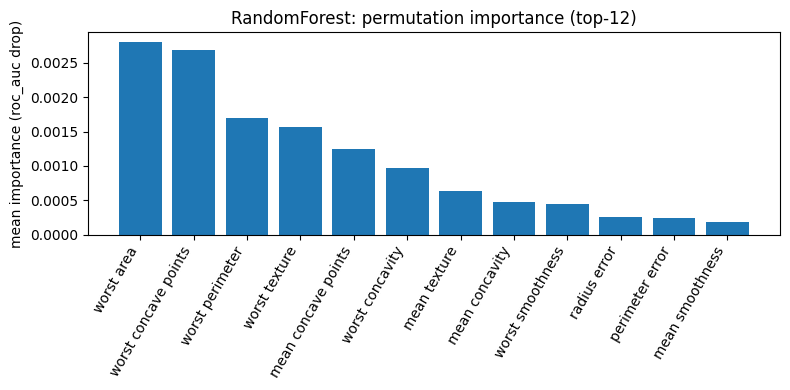

In [27]:
perm = permutation_importance(
    rf_tab, X_test, y_test,
    n_repeats=8,
    random_state=RANDOM_STATE,
    scoring="roc_auc"
)

pimp = perm.importances_mean
idx = np.argsort(pimp)[::-1][:12]

plt.figure(figsize=(8, 4))
plt.bar(range(len(idx)), pimp[idx])
plt.xticks(range(len(idx)), [feature_names[i] for i in idx], rotation=60, ha="right")
plt.ylabel("mean importance (roc_auc drop)")
plt.title("RandomForest: permutation importance (top-12)")
plt.tight_layout()
plt.show()

Bagging уменьшает variance: много деревьев на bootstrap‑выборках - ответы усредняются - модель устойчивее.
Random Forest добавляет случайность по признакам - деревья менее коррелированы - ансамбль обычно сильнее.
OOB-score - удобная быстрая оценка качества для ансамблей на bootstrap, но для серьёзной оценки всё равно нужен корректный протокол (hold-out/CV).
Важность признаков полезна как диагностика: сначала быстро (feature_importances_), затем надёжнее проверяем permutation importance.

Boosting и Stacking

Вспомогательные функции

In [28]:
def print_metrics(y_true, y_pred, y_proba=None, title=None):
    # Печатаем несколько полезных метрик для бинарной классификации.
    # ROC-AUC считаем только если есть вероятности/скор (y_proba).
    if title:
        print(title)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"accuracy = {acc:.4f}")
    print(f"f1       = {f1:.4f}")
    if y_proba is not None:
        try:
            auc = roc_auc_score(y_true, y_proba)
            print(f"roc_auc  = {auc:.4f}")
        except Exception:
            # На случай, если y_proba по каким-то причинам некорректный (редко, но бывает)
            pass
    print("confusion_matrix:")
    print(confusion_matrix(y_true, y_pred))
    print()

def plot_decision_boundary_2d(model, X, y, title=None, steps=350):
    # Визуализация границы решения для 2D-данных:
    # 1) строим сетку точек (grid) на плоскости признаков,
    # 2) предсказываем класс для каждой точки,
    # 3) рисуем фон (contourf) и поверх – реальные точки.
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, steps),
                         np.linspace(y_min, y_max, steps))
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, zz, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=20)
    if title:
        plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

def eval_binary(model, X_train, y_train, X_test, y_test, title=None):
    # Мини-обёртка: обучить модель на train и оценить на test.
    # Возвращаем обученную модель – её удобно дальше использовать (например, рисовать границу).
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = None
    if hasattr(model, "predict_proba"):
        # Для ROC-AUC нужна "уверенность" модели: вероятность положительного класса
        proba = model.predict_proba(X_test)[:, 1]
    print_metrics(y_test, pred, y_proba=proba, title=title)
    return model

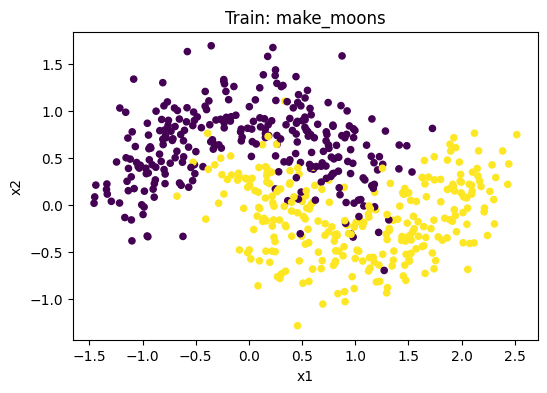

In [29]:
X, y = make_moons(n_samples=800, noise=0.28, random_state=RANDOM_STATE)

# Честное разбиение на train/test (стратификация сохраняет доли классов)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

# Сначала просто посмотрим на точки train
plt.figure(figsize=(6, 4))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=20)
plt.title("Train: make_moons")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()


BOOSTING

Boosting строит ансамбль последовательно: каждая следующая модель пытается исправить ошибки предыдущих.

Boosting способен собирать из слабых моделей сильную

Классический AdaBoost часто используют с решающими пнями (деревья глубины 1). Идея (очень упрощённо):

после очередной итерации "сложные" объекты получают больший вес;
следующая модель больше "внимания" уделяет именно этим объектам;
итог – взвешенная комбинация многих слабых моделей.
Важно помнить две ручки:

n_estimators – сколько итераций (сколько слабых моделей в ансамбле);
learning_rate – насколько "сильным" будет вклад каждой итерации.

AdaBoost (stumps) – test
accuracy = 0.9250
f1       = 0.9237
roc_auc  = 0.9809
confusion_matrix:
[[113   7]
 [ 11 109]]



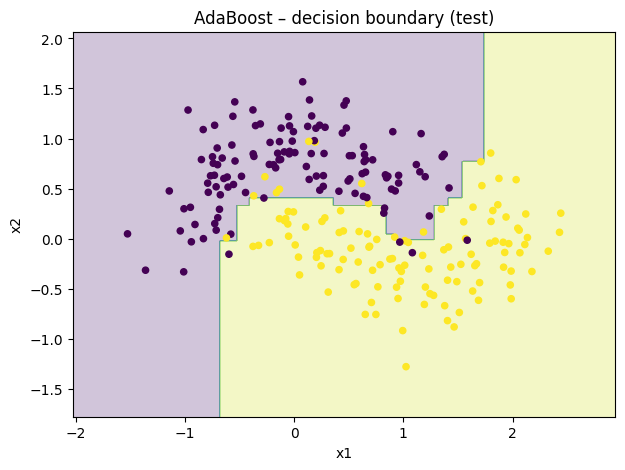

In [30]:
# слабая модель
stump = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)

# AdaBoost
ada = AdaBoostClassifier(
    estimator=stump,
    n_estimators=200,
    learning_rate=0.6,
    random_state=RANDOM_STATE
)

ada = eval_binary(ada, X_train, y_train, X_test, y_test, title="AdaBoost (stumps) – test")

plot_decision_boundary_2d(ada, X_test, y_test, title="AdaBoost – decision boundary (test)")

Влияние количества пней на каество 

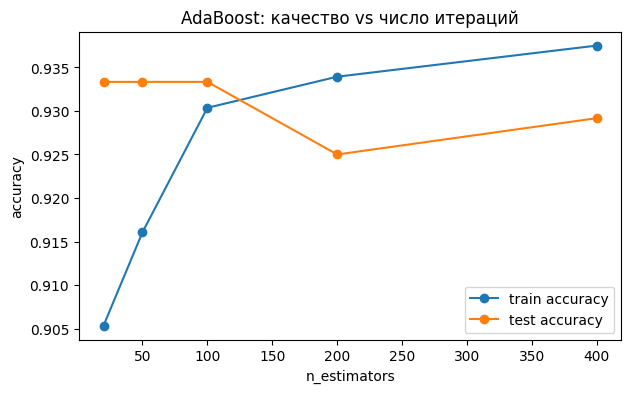

In [31]:
n_estimators_grid = [20, 50, 100, 200, 400]
train_acc = []
test_acc = []

for n_est in n_estimators_grid:
    m = AdaBoostClassifier(estimator=stump, n_estimators=n_est, learning_rate=0.6, random_state=RANDOM_STATE)
    m.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, m.predict(X_train)))
    test_acc.append(accuracy_score(y_test, m.predict(X_test)))

# График "учебной кривой" (очень упрощённой): train и test accuracy
plt.figure(figsize=(7, 4))
plt.plot(n_estimators_grid, train_acc, marker="o", label="train accuracy")
plt.plot(n_estimators_grid, test_acc, marker="o", label="test accuracy")
plt.xlabel("n_estimators")
plt.ylabel("accuracy")
plt.title("AdaBoost: качество vs число итераций")
plt.legend()
plt.show()

Gradient Boosting

Gradient Boosting тоже строит ансамбль последовательно, но интерпретация другая: мы добавляем модель так, чтобы уменьшать функцию потерь (градиентный шаг).

GradientBoosting – test
accuracy = 0.9250
f1       = 0.9217
roc_auc  = 0.9797
confusion_matrix:
[[116   4]
 [ 14 106]]



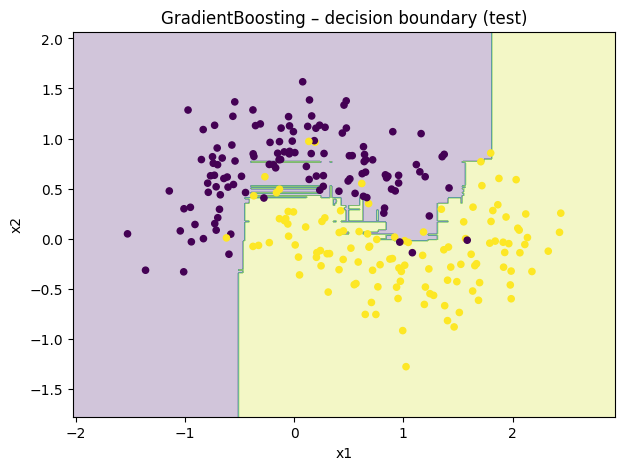

In [32]:
gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=2,
    random_state=RANDOM_STATE
)

gb = eval_binary(gb, X_train, y_train, X_test, y_test, title="GradientBoosting – test")
plot_decision_boundary_2d(gb, X_test, y_test, title="GradientBoosting – decision boundary (test)")


Sanity-check

Влияние глубины базовых деревьев на качество

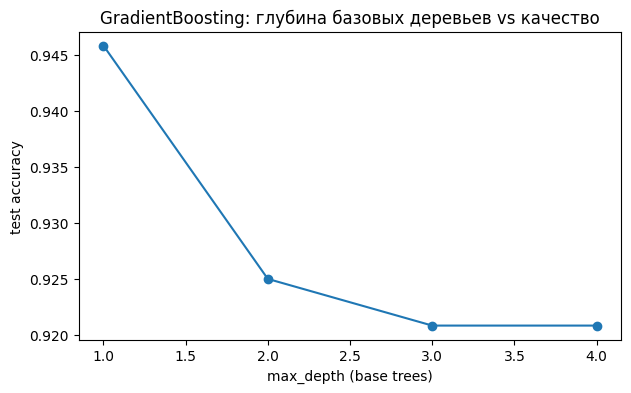

In [33]:
depths = [1, 2, 3, 4]
test_scores = []

for d in depths:
    m = GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=d,
        random_state=RANDOM_STATE
    )
    m.fit(X_train, y_train)
    test_scores.append(accuracy_score(y_test, m.predict(X_test)))

plt.figure(figsize=(7, 4))
plt.plot(depths, test_scores, marker="o")
plt.xlabel("max_depth (base trees)")
plt.ylabel("test accuracy")
plt.title("GradientBoosting: глубина базовых деревьев vs качество")
plt.show()

STACKING

Stacking – это ансамбль “другого типа”:

несколько базовых моделей дают предсказания;
мы обучаем метамодель, которая учится их комбинировать.
Почему это может работать:

разные модели ошибаются по-разному;
метамодель учится “кому доверять” в разных областях пространства признаков.
Метамодель должна учиться на out-of-fold (OOF) предсказаниях базовых моделей:

для каждой точки train предсказание должно быть сделано моделью, которая не видела эту точку при обучении;
иначе получится утечка, и метамодель “подсмотрит” ответы.

StackingClassifier – test
accuracy = 0.9208
f1       = 0.9177
roc_auc  = 0.9776
confusion_matrix:
[[115   5]
 [ 14 106]]



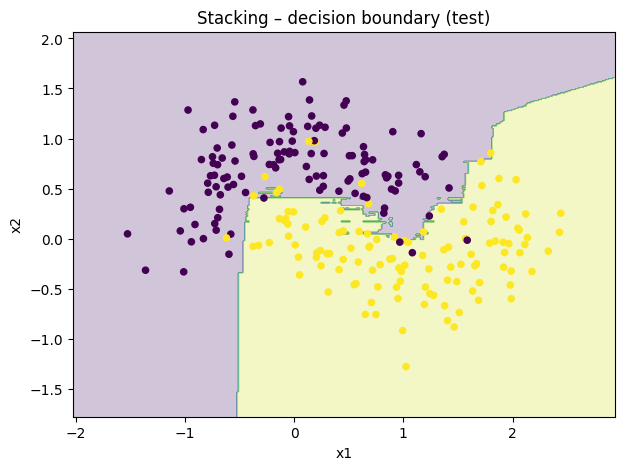

In [34]:
# Создаем несколько базовых моделей
# Должны быть разными
estimators = [
    ("lr", Pipeline([("scaler", StandardScaler()), ("lr", LogisticRegression(max_iter=2000))])),
    ("rf", RandomForestClassifier(n_estimators=250, random_state=RANDOM_STATE, n_jobs=-1)),
    ("gb", GradientBoostingClassifier(n_estimators=250, learning_rate=0.05, max_depth=2, random_state=RANDOM_STATE)),
]

final_est = LogisticRegression(max_iter=2000)

# cv - важно
stack = StackingClassifier(
    estimators=estimators,
    final_estimator=final_est,
    cv=5,
    n_jobs=-1,
    passthrough=False  # если True, метамодель видит и исходные признаки тоже
)

stack = eval_binary(stack, X_train, y_train, X_test, y_test, title="StackingClassifier – test")
plot_decision_boundary_2d(stack, X_test, y_test, title="Stacking – decision boundary (test)")

Реальный датасет

Мы будем смотреть:

accuracy (доля верных ответов),
F1 (баланс precision/recall, полезно при перекосе классов),
ROC-AUC (качество ранжирования вероятностей, менее зависит от выбранного порога 0.5),
confusion matrix (какие ошибки делаем: FP/FN).

In [35]:
data = load_breast_cancer()
X = data["data"]
y = data["target"]
feature_names = list(data["feature_names"])


# Разбиваем на train/test со стратификацией.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

# Baseline: простая модель, с которой удобно сравнивать более сложные.
# baseline: логистическая регрессия (с масштабированием)
lr = Pipeline([("scaler", StandardScaler()), ("lr", LogisticRegression(max_iter=3000))])
lr = eval_binary(lr, X_train, y_train, X_test, y_test, title="Tabular – LogisticRegression (baseline)")

# RandomForest: bagging-ансамбль. Часто даёт неплохой старт, но бустинг нередко сильнее.
# RandomForest (контекст)
rf = RandomForestClassifier(n_estimators=600, random_state=RANDOM_STATE, n_jobs=-1, oob_score=True)
rf = eval_binary(rf, X_train, y_train, X_test, y_test, title="Tabular – RandomForest")
# OOB-score (out-of-bag) – внутренняя оценка для RF; здесь выводим для иллюстрации.
print(f"RandomForest oob_score_ = {rf.oob_score_:.4f}\n")

# GradientBoosting: последовательное уменьшение функции потерь (классический GBDT).
# Boosting: GradientBoosting
gb = GradientBoostingClassifier(n_estimators=600, learning_rate=0.03, max_depth=2, random_state=RANDOM_STATE)
gb = eval_binary(gb, X_train, y_train, X_test, y_test, title="Tabular – GradientBoosting")

# HistGradientBoosting: более быстрый вариант (особенно на больших данных).
# Boosting (быстрый): HistGradientBoosting
hgb = HistGradientBoostingClassifier(random_state=RANDOM_STATE, max_depth=3, learning_rate=0.05)
hgb = eval_binary(hgb, X_train, y_train, X_test, y_test, title="Tabular – HistGradientBoosting")

# Stacking: комбинируем разные модели. Важно: внутри будет CV (cv=5) → честное обучение метамодели.
# Stacking: смешаем baseline + RF + boosting
estimators_tab = [
    ("lr", Pipeline([("scaler", StandardScaler()), ("lr", LogisticRegression(max_iter=3000))])),
    ("rf", RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1)),
    ("gb", GradientBoostingClassifier(n_estimators=400, learning_rate=0.05, max_depth=2, random_state=RANDOM_STATE)),
]
stack_tab = StackingClassifier(estimators=estimators_tab, final_estimator=LogisticRegression(max_iter=3000), cv=5, n_jobs=-1)
stack_tab = eval_binary(stack_tab, X_train, y_train, X_test, y_test, title="Tabular – StackingClassifier")

Tabular – LogisticRegression (baseline)
accuracy = 0.9860
f1       = 0.9889
roc_auc  = 0.9977
confusion_matrix:
[[52  1]
 [ 1 89]]

Tabular – RandomForest
accuracy = 0.9580
f1       = 0.9670
roc_auc  = 0.9943
confusion_matrix:
[[49  4]
 [ 2 88]]

RandomForest oob_score_ = 0.9624

Tabular – GradientBoosting
accuracy = 0.9580
f1       = 0.9670
roc_auc  = 0.9935
confusion_matrix:
[[49  4]
 [ 2 88]]

Tabular – HistGradientBoosting
accuracy = 0.9580
f1       = 0.9674
roc_auc  = 0.9948
confusion_matrix:
[[48  5]
 [ 1 89]]

Tabular – StackingClassifier
accuracy = 0.9720
f1       = 0.9780
roc_auc  = 0.9973
confusion_matrix:
[[50  3]
 [ 1 89]]



*Boosting (AdaBoost/GBDT/HGB) – последовательное построение ансамбля. Часто даёт сильное качество “из коробки”,
но чувствителен к настройкам (learning_rate, глубина базовых деревьев, число итераций) и легко переобучается при агрессивных параметрах.

Stacking – способ “смешать” разные модели через метамодель. Может дать прирост, когда базовые модели действительно разные,-
но его нельзя делать “в лоб”: метамодель должна учиться на OOF предсказаниях (через CV), иначе будет утечка.